# Quantification of asymmetry

This code calculates the kuramoto parameter (χ) as a measure of asymmetry of force distribution around the cell perimeter. 
The positions of fully extended cilia corresponding to the individual wavefronts are previously manually identified and their x and y pixel coordinates are saved in a txt file. These points are treated as individual oscillator phases to calculate χ. 

**Input:**

*file_directory*: Path to folder of the file with the manually detected wavefront positions

*file_name*: The name of the txt file with the wavefront positions

*input_parameters_path*: The path to the parameter file with the pixel_size, and detected cell radius

**Output:**

*kuramoto_parameter.csv*: A csv file with the measured kuramoto parameter and the number of wavefronts. 

In [ ]:
import csv 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Input

In [2]:
### Path to folder of the file with the manually detected wavefront positions
file_directory = "C:\\Users\\kourkoul\\SCRIPTS\\Paper_scripts\\example_data\\"
file_name = "cell_01_wavefronts_positions.txt"

### Reading the parameters file
input_parameters_path = file_directory + "parameters.csv"
input_parameters = pd.read_csv(input_parameters_path)

### Pixel size and framerate of timelapse:
pixel_size = input_parameters["pixel_size"][0]  # μm 
radius     = input_parameters["radius"][0]         # μm

### Conversion to angles

In [3]:
### Load positions
wf_positions = []

with open(file_directory + file_name, 'r') as file:
    for line in file:
        x, y = map(float, line.split())
        wf_positions.append((x, y))

x_positions, y_positions = zip(*wf_positions)

In [4]:
x_positions = np.array(x_positions)
y_positions = np.array(y_positions)

dx = np.diff(x_positions)
dy = np.diff(y_positions)

wf_distances = np.sqrt(dx**2 + dy**2)   
wf_distances = np.append(wf_distances,np.sqrt((x_positions[0]-x_positions[-1])**2 + (y_positions[0]-y_positions[-1])**2))
wf_distances_microns = wf_distances*pixel_size

theta = 2 * np.arcsin(wf_distances_microns / (2 * radius))
theta_absolute = np.cumsum(theta)
theta_absolute = np.mod(theta_absolute, 2 * np.pi)

N = len(theta_absolute)

### Calculation of kuramoto parameter

0.08355497338284491


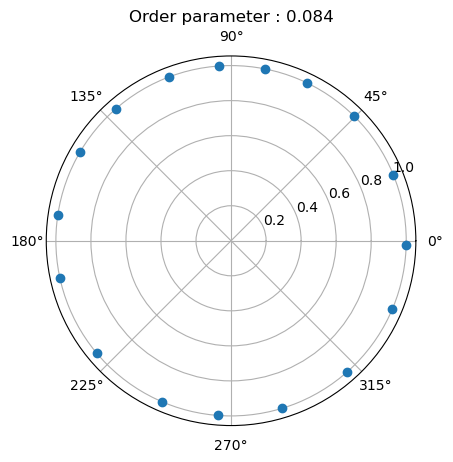

In [5]:
### Calculate order parameter
def order_parameter(theta):
    return np.abs(np.sum(np.exp(1j * theta)) / N)

chi_value = order_parameter(theta_absolute)
print(chi_value)

### Visualization
plt.figure()
plt.polar(theta_absolute, np.ones(N), 'o')  # Plot wavefronts on the unit circle
plt.title("Order parameter : " + str(round(chi_value, 3)))
plt.show()

### Saving output

In [6]:
headers = ["chi", "N"]
values = [chi_value, N]

with open(file_directory +'kuramoto_parameter.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(headers)
    writer.writerow(values)